BASIC HARRIS CORNER DETECTION


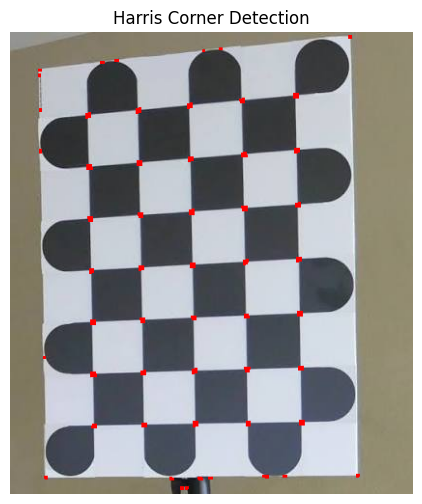

Strong Harris response pixels: 1478

TASK 11 - Compare Two Different Images


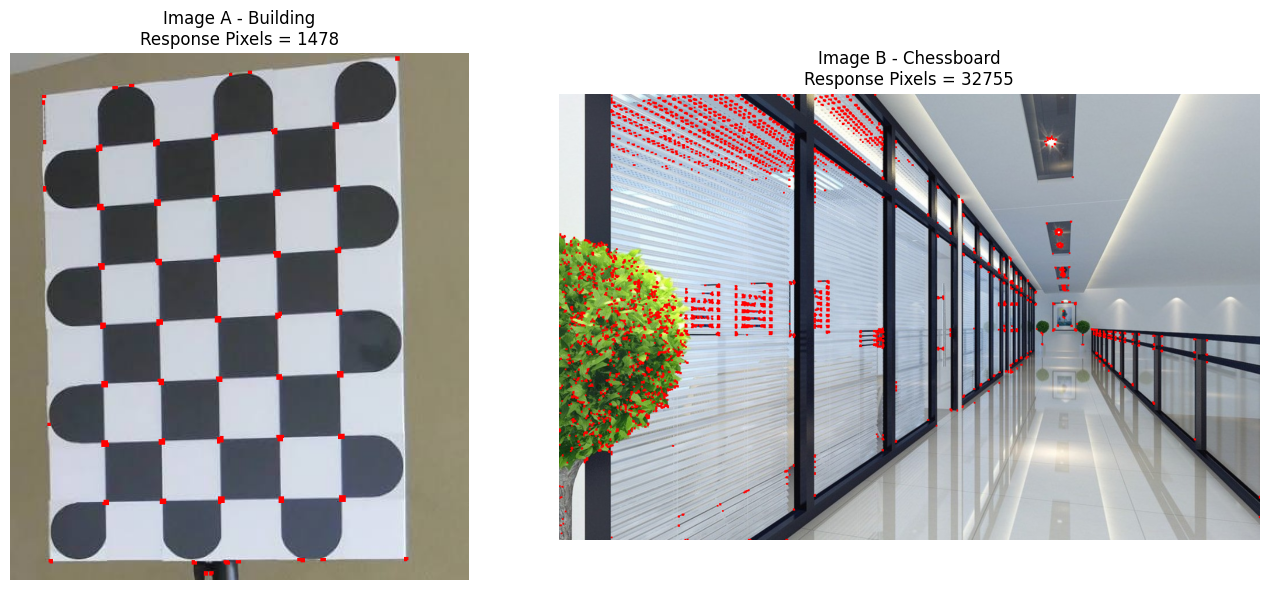

Image A response pixels: 1478
Image B response pixels: 32755

TASK 12 - Rotation Experiment


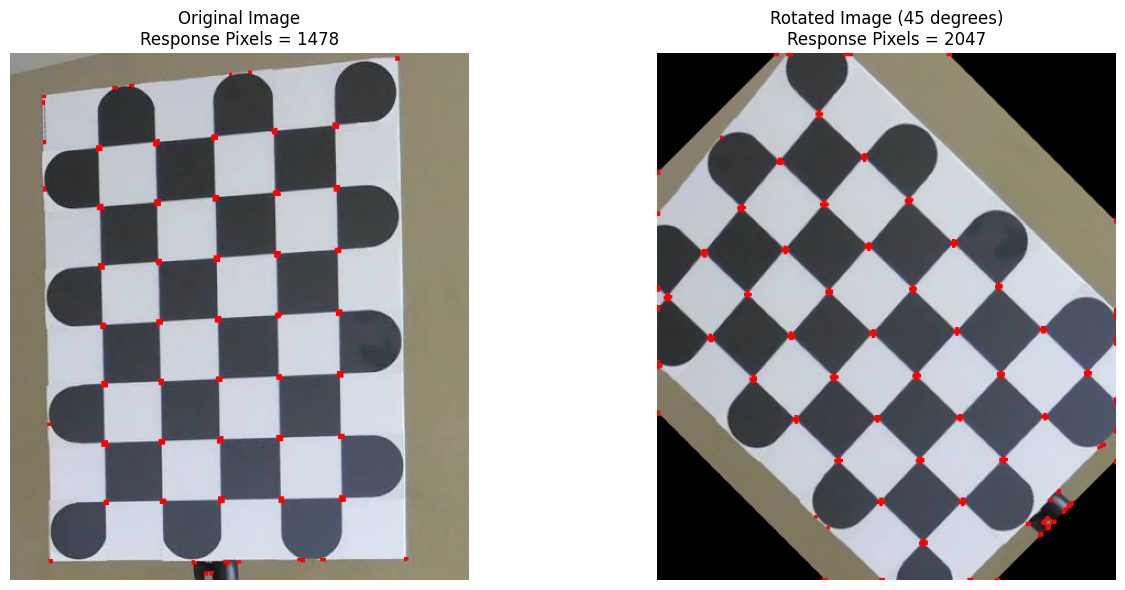

Original response pixels: 1478
Rotated response pixels: 2047

TASK 13 - Scale Experiment


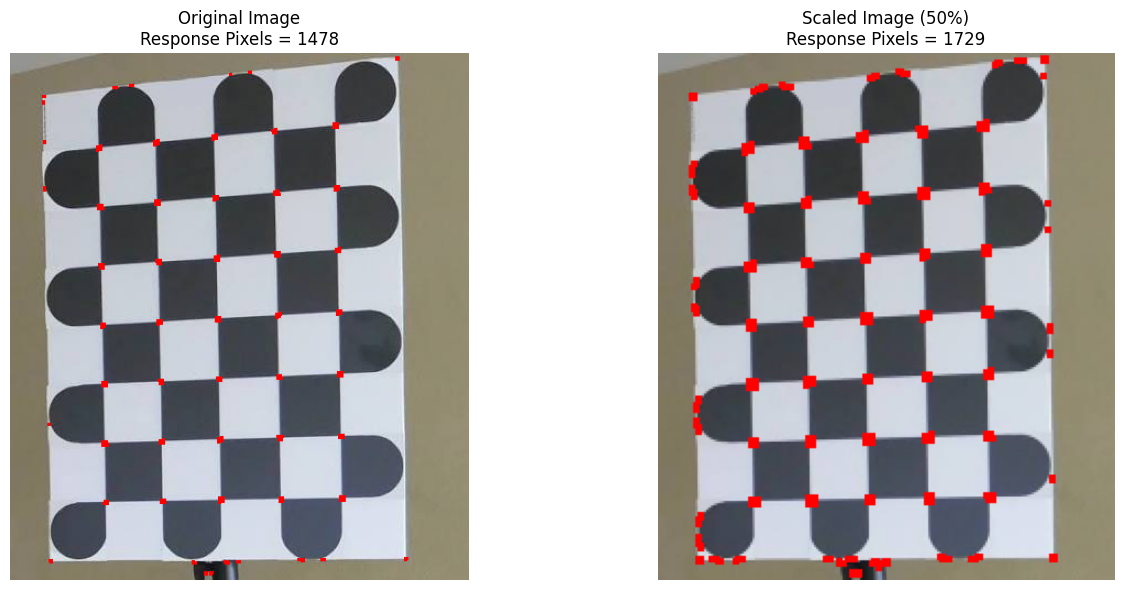

Original response pixels: 1478
Scaled response pixels: 1729

Additional Scale Test


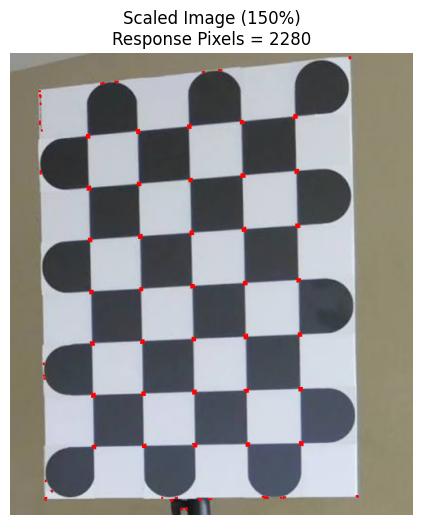


SUMMARY
Original image response pixels: 1478
Rotated image response pixels: 2047
Scaled 50% response pixels: 1729
Scaled 150% response pixels: 2280

Task 11:
Different images produce different Harris responses,
even when identical detector parameters are used.

Task 12:
Harris Corner Detection is generally robust to rotation.

Task 13:
Harris Corner Detection is NOT scale invariant.
Changing the image size may change which corners are detected.

Program completed successfully.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# FUNCTION: Apply Harris Corner Detection
# ============================================================

def harris_corner_detection(
    image,
    block_size=2,
    ksize=3,
    k=0.04,
    threshold_ratio=0.01
):
    """
    Apply Harris Corner Detection and return:
    - original image with detected corners
    - Harris response
    - number of strong response pixels
    """

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # Harris requires float32
    gray = np.float32(gray)

    # Harris Corner Detection
    dst = cv2.cornerHarris(
        gray,
        blockSize=block_size,
        ksize=ksize,
        k=k
    )

    # Dilate responses for display
    dst = cv2.dilate(
        dst,
        None
    )

    # Create result image
    result = image.copy()

    # Threshold
    threshold = (
        threshold_ratio * dst.max()
    )

    # Create corner mask
    corner_mask = (
        dst > threshold
    )

    # Mark detected corners in red
    result[corner_mask] = [0, 0, 255]

    # Count strong Harris response pixels
    number_of_response_pixels = np.count_nonzero(
        corner_mask
    )

    return (
        result,
        dst,
        number_of_response_pixels
    )


# ============================================================
# DEFAULT PARAMETERS
# ============================================================

BLOCK_SIZE = 2
KSIZE = 3
K = 0.04
THRESHOLD_RATIO = 0.01


# ============================================================
# BASIC HARRIS CORNER DETECTION
# ============================================================

print("BASIC HARRIS CORNER DETECTION")


# Read image
img = cv2.imread(
    "assets/chess2.jpg"
)

if img is None:
    raise FileNotFoundError(
        "building.jpg could not be found."
    )


# Apply Harris Corner Detection
result, dst, count = harris_corner_detection(
    img,
    block_size=BLOCK_SIZE,
    ksize=KSIZE,
    k=K,
    threshold_ratio=THRESHOLD_RATIO
)


# Convert for Matplotlib
result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)


# Display
plt.figure(
    figsize=(10, 6)
)

plt.imshow(
    result_rgb
)

plt.title(
    "Harris Corner Detection"
)

plt.axis(
    "off"
)

plt.show()


print(
    "Strong Harris response pixels:",
    count
)


# ============================================================
# TASK 11 - COMPARE TWO DIFFERENT IMAGES
# ============================================================

print(
    "\nTASK 11 - Compare Two Different Images"
)


# Image A
image_a = cv2.imread(
    "assets/chess2.jpg"
)


# Image B
image_b = cv2.imread(
    "assets/corridor.jpg"
)


if image_a is None:
    raise FileNotFoundError(
        "building.jpg could not be found."
    )


if image_b is None:
    raise FileNotFoundError(
        "chessboard.jpg could not be found."
    )


# Apply same Harris parameters to both images
result_a, dst_a, count_a = harris_corner_detection(
    image_a,
    BLOCK_SIZE,
    KSIZE,
    K,
    THRESHOLD_RATIO
)

result_b, dst_b, count_b = harris_corner_detection(
    image_b,
    BLOCK_SIZE,
    KSIZE,
    K,
    THRESHOLD_RATIO
)


# Convert to RGB
result_a_rgb = cv2.cvtColor(
    result_a,
    cv2.COLOR_BGR2RGB
)

result_b_rgb = cv2.cvtColor(
    result_b,
    cv2.COLOR_BGR2RGB
)


# Display comparison
plt.figure(
    figsize=(14, 6)
)


plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    result_a_rgb
)

plt.title(
    f"Image A - Building\n"
    f"Response Pixels = {count_a}"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    result_b_rgb
)

plt.title(
    f"Image B - Chessboard\n"
    f"Response Pixels = {count_b}"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


print(
    "Image A response pixels:",
    count_a
)

print(
    "Image B response pixels:",
    count_b
)


# ============================================================
# TASK 12 - ROTATION EXPERIMENT
# ============================================================

print(
    "\nTASK 12 - Rotation Experiment"
)


# Get image dimensions
height, width = img.shape[:2]


# Centre of image
center = (
    width // 2,
    height // 2
)


# Rotation angle
angle = 45


# Create rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    angle,
    1.0
)


# Rotate image
rotated_image = cv2.warpAffine(
    img,
    rotation_matrix,
    (width, height)
)


# Apply Harris to original image
original_result, _, original_count = harris_corner_detection(
    img,
    BLOCK_SIZE,
    KSIZE,
    K,
    THRESHOLD_RATIO
)


# Apply Harris to rotated image
rotated_result, _, rotated_count = harris_corner_detection(
    rotated_image,
    BLOCK_SIZE,
    KSIZE,
    K,
    THRESHOLD_RATIO
)


# Convert to RGB
original_result_rgb = cv2.cvtColor(
    original_result,
    cv2.COLOR_BGR2RGB
)

rotated_result_rgb = cv2.cvtColor(
    rotated_result,
    cv2.COLOR_BGR2RGB
)


# Display comparison
plt.figure(
    figsize=(14, 6)
)


plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    original_result_rgb
)

plt.title(
    f"Original Image\n"
    f"Response Pixels = {original_count}"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    rotated_result_rgb
)

plt.title(
    f"Rotated Image ({angle} degrees)\n"
    f"Response Pixels = {rotated_count}"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


print(
    "Original response pixels:",
    original_count
)

print(
    "Rotated response pixels:",
    rotated_count
)


# ============================================================
# TASK 13 - SCALE EXPERIMENT
# ============================================================

print(
    "\nTASK 13 - Scale Experiment"
)


# Resize image to 50%
scaled_image = cv2.resize(
    img,
    None,
    fx=0.5,
    fy=0.5,
    interpolation=cv2.INTER_AREA
)


# Apply Harris Corner Detection
scaled_result, _, scaled_count = harris_corner_detection(
    scaled_image,
    BLOCK_SIZE,
    KSIZE,
    K,
    THRESHOLD_RATIO
)


# Convert to RGB
scaled_result_rgb = cv2.cvtColor(
    scaled_result,
    cv2.COLOR_BGR2RGB
)


# Display
plt.figure(
    figsize=(14, 6)
)


plt.subplot(
    1,
    2,
    1
)

plt.imshow(
    original_result_rgb
)

plt.title(
    f"Original Image\n"
    f"Response Pixels = {original_count}"
)

plt.axis(
    "off"
)


plt.subplot(
    1,
    2,
    2
)

plt.imshow(
    scaled_result_rgb
)

plt.title(
    f"Scaled Image (50%)\n"
    f"Response Pixels = {scaled_count}"
)

plt.axis(
    "off"
)


plt.tight_layout()
plt.show()


print(
    "Original response pixels:",
    original_count
)

print(
    "Scaled response pixels:",
    scaled_count
)


# ============================================================
# OPTIONAL SECOND SCALE EXPERIMENT
# ============================================================

print(
    "\nAdditional Scale Test"
)


# Enlarge image to 150%
scaled_large = cv2.resize(
    img,
    None,
    fx=1.5,
    fy=1.5,
    interpolation=cv2.INTER_LINEAR
)


scaled_large_result, _, scaled_large_count = (
    harris_corner_detection(
        scaled_large,
        BLOCK_SIZE,
        KSIZE,
        K,
        THRESHOLD_RATIO
    )
)


scaled_large_rgb = cv2.cvtColor(
    scaled_large_result,
    cv2.COLOR_BGR2RGB
)


plt.figure(
    figsize=(10, 6)
)

plt.imshow(
    scaled_large_rgb
)

plt.title(
    f"Scaled Image (150%)\n"
    f"Response Pixels = {scaled_large_count}"
)

plt.axis(
    "off"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print(
    "\n============================================"
)

print(
    "SUMMARY"
)

print(
    "============================================"
)


print(
    "Original image response pixels:",
    original_count
)

print(
    "Rotated image response pixels:",
    rotated_count
)

print(
    "Scaled 50% response pixels:",
    scaled_count
)

print(
    "Scaled 150% response pixels:",
    scaled_large_count
)


print(
    "\nTask 11:"
)

print(
    "Different images produce different Harris responses,"
)

print(
    "even when identical detector parameters are used."
)


print(
    "\nTask 12:"
)

print(
    "Harris Corner Detection is generally robust to rotation."
)


print(
    "\nTask 13:"
)

print(
    "Harris Corner Detection is NOT scale invariant."
)

print(
    "Changing the image size may change which corners are detected."
)


print(
    "\nProgram completed successfully."
)